## Zeitkontinuierliches Sinussignal

Punkte: 20000, Schrittweite: 5.00 us, Perioden: 5


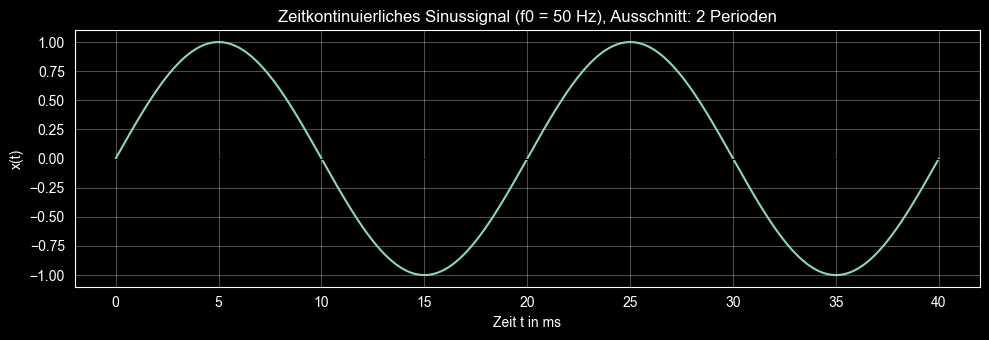

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Zeitkontinuierliches Signal x(t) = A * sin(2*pi*f0*t + phi) ---
# kontinuierlich wird hier durch sehr feine Abtastung angenÃƒÆ’Ã‚Â¤hert
A   = 1.0        # Amplitude
f0  = 50.0       # Signalfrequenz in Hz
phi = 0.0        # Phase in rad
T   = 0.1        # betrachtete Dauer in s

fs_cont = 200_000.0                              # quasi-kontinuierliche Aufloesung
t = np.arange(0.0, T, 1.0 / fs_cont)             # Zeitachse
x = A * np.sin(2 * np.pi * f0 * t + phi)         # Signalwerte

print(f"Punkte: {t.size}, Schrittweite: {1/fs_cont*1e6:.2f} us, Perioden: {T*f0:.0f}")

# --- Ausschnitt plotten: die ersten 2 Perioden ---
t_end = 2 / f0
m = t <= t_end

plt.figure(figsize=(10, 3.5))
plt.plot(t[m] * 1e3, x[m], lw=1.5)
plt.title(f"Zeitkontinuierliches Sinussignal (f0 = {f0:.0f} Hz), Ausschnitt: 2 Perioden")
plt.xlabel("Zeit t in ms")
plt.ylabel("x(t)")
plt.grid(True, alpha=0.3)
plt.axhline(0, color="k", lw=0.8)
plt.tight_layout()
plt.show()

## Zeitdiskretes Sinussignal (abgetastet)

fs = 1000 Hz, Ts = 1.00 ms, Samples = 100, Samples/Periode = 20.0, Omega = 0.314 rad


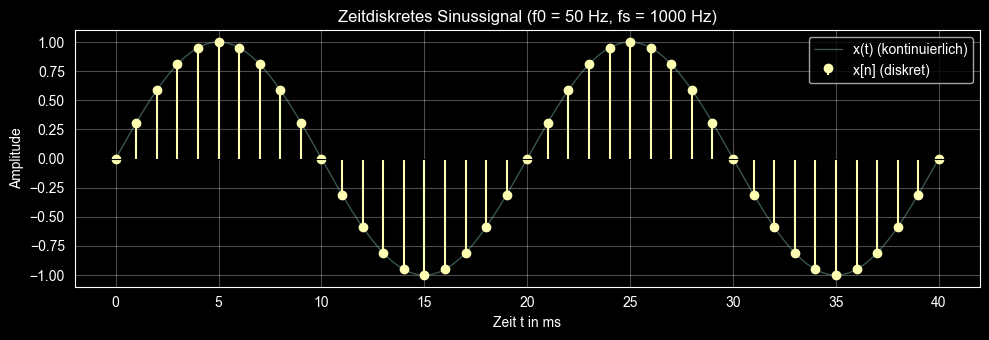

In [2]:
# --- Zeitdiskretes Signal x[n] = x(n*Ts) = A * sin(2*pi*f0/fs*n + phi) ---
fs = 1000.0                       # Abtastrate in Hz (>> 2*f0 = 100 Hz -> Abtasttheorem erfuellt)
Ts = 1.0 / fs                     # Abtastintervall

n  = np.arange(0, int(T * fs))    # Abtastindizes
tn = n * Ts                       # zugehoerige Abtastzeitpunkte
xn = A * np.sin(2 * np.pi * f0 * tn + phi)

Omega = 2 * np.pi * f0 / fs       # normierte Kreisfrequenz in rad/Abtastwert
print(f"fs = {fs:.0f} Hz, Ts = {Ts*1e3:.2f} ms, Samples = {n.size}, "
      f"Samples/Periode = {fs/f0:.1f}, Omega = {Omega:.3f} rad")

# --- Ausschnitt plotten: die ersten 2 Perioden, kontinuierlich als Referenz ---
mn = tn <= t_end

plt.figure(figsize=(10, 3.5))
plt.plot(t[m] * 1e3, x[m], lw=1.0, alpha=0.4, label="x(t) (kontinuierlich)")
plt.stem(tn[mn] * 1e3, xn[mn], basefmt=" ", linefmt="C1-", markerfmt="C1o", label="x[n] (diskret)")
plt.title(f"Zeitdiskretes Sinussignal (f0 = {f0:.0f} Hz, fs = {fs:.0f} Hz)")
plt.xlabel("Zeit t in ms")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.axhline(0, color="k", lw=0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Ganzzahlige Verzoegerung um 5 ms (D = 5 Samples)

tau = 5.00 ms entspricht D = 5.000 Samples (Ts = 1.00 ms)


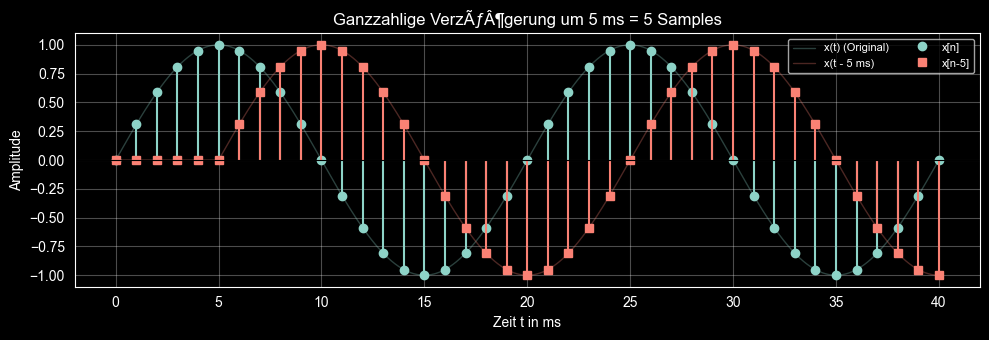

In [3]:
# VerzÃƒÂ¶gerung um 5 ms: ganzzahliges Vielfaches von Ts -> kein Fractional Delay nÃƒÂ¶tig
tau = 5e-3                        # gewÃƒÂ¼nschte VerzÃƒÂ¶gerung in s
D   = tau * fs                    # VerzÃƒÂ¶gerung in Samples
print(f"tau = {tau*1e3:.2f} ms entspricht D = {D:.3f} Samples (Ts = {Ts*1e3:.2f} ms)")

D = int(round(D))

# VerzÃƒÂ¶gerung = Verschiebung des Index: y[n] = x[n - D], vorne mit Nullen aufgefÃƒÂ¼llt
xn_del = np.concatenate([np.zeros(D), xn[:-D]])

# Referenz: kontinuierliches Signal um tau verzÃƒÂ¶gert (nur zum Vergleich im Plot)
x_del = A * np.sin(2 * np.pi * f0 * (t - tau) + phi)
x_del[t < tau] = 0.0

# --- Ausschnitt plotten: die ersten 2 Perioden ---
plt.figure(figsize=(10, 3.5))
plt.plot(t[m] * 1e3, x[m], lw=1.0, alpha=0.3, color="C0", label="x(t) (Original)")
plt.plot(t[m] * 1e3, x_del[m], lw=1.0, alpha=0.3, color="C3", label=f"x(t - {tau*1e3:.0f} ms)")
plt.stem(tn[mn] * 1e3, xn[mn], basefmt=" ", linefmt="C0-", markerfmt="C0o", label="x[n]")
plt.stem(tn[mn] * 1e3, xn_del[mn], basefmt=" ", linefmt="C3-", markerfmt="C3s", label=f"x[n-{D}]")
plt.title(f"Ganzzahlige VerzÃƒÂ¶gerung um {tau*1e3:.0f} ms = {D} Samples")
plt.xlabel("Zeit t in ms")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.axhline(0, color="k", lw=0.8)
plt.legend(loc="upper right", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Fraktionale Verzoegerung mit gefenstertem Sinc

In [4]:
# --- Fraktionale Verzoegerung: gefensterter Sinc-Interpolator (Windowed-Sinc-FIR) ---
# Idee: die ideale Verzoegerung um mu Samples hat die Impulsantwort h[k] = sinc(k - mu).
# Die ist unendlich lang und nicht kausal -> um M verschieben, auf N Taps kuerzen
# und mit einem Fenster (hier Hann) glaetten, damit das Abschneiden nicht klingelt.

def frac_delay_fir(mu, N=21):
    """FIR-Koeffizienten fuer eine Verzoegerung um (M + mu) Samples, M = (N-1)//2."""
    if N % 2 == 0:
        raise ValueError("N ungerade waehlen, damit die Mitte auf einem Tap liegt")
    M = (N - 1) // 2
    k = np.arange(N)
    h = np.sinc(k - M - mu)          # np.sinc(x) = sin(pi*x)/(pi*x), also schon normiert
    w = np.hanning(N + 2)[1:-1]      # Hann-Fenster ohne die beiden Nullen an den Raendern
    h = h * w
    h = h / h.sum()                  # DC-Normierung: Gleichanteil bleibt erhalten
    return h, M

def frac_delay(x, tau, fs, N=21):
    """Verzoegert das Signal x um tau Sekunden (beliebig, nicht nur Vielfache von Ts)."""
    D = tau * fs                     # Verzoegerung in Samples, z.B. 5.5
    D_int = int(np.floor(D))         # ganzzahliger Anteil -> reine Indexverschiebung
    mu = D - D_int                   # gebrochener Anteil in [0, 1) -> Filter
    h, M = frac_delay_fir(mu, N)

    # 'full'-Faltung, dann die Gruppenlaufzeit M des Filters wieder herausschneiden
    # -> y hat gegenueber x genau die Verzoegerung mu
    y = np.convolve(x, h)[M:M + len(x)]

    # restliche ganzzahlige Verzoegerung anhaengen (kausal, vorne mit Nullen)
    if D_int > 0:
        y = np.concatenate([np.zeros(D_int), y[:-D_int]])
    return y, h, D_int, mu

# --- Anwendung: 5.5 ms, also 5.5 Samples bei fs = 1000 Hz ---
tau_frac = 5.5e-3
N_taps = 21
xn_frac, h, D_int, mu = frac_delay(xn, tau_frac, fs, N=N_taps)

print(f"tau = {tau_frac*1e3:.2f} ms = {tau_frac*fs:.2f} Samples")
print(f"  ganzzahliger Anteil D_int = {D_int}, gebrochener Anteil mu = {mu:.3f}")
print(f"  FIR-Laenge N = {N_taps}, Summe der Koeffizienten = {h.sum():.6f}")
print("  h =", np.array2string(h, precision=3, suppress_small=True))

# Referenz: analytisch exakt verzoegertes Signal, um den Fehler beurteilen zu koennen
xn_ref = A * np.sin(2 * np.pi * f0 * (tn - tau_frac) + phi)
xn_ref[tn < tau_frac] = 0.0

# Einschwingbereich des Filters (erste D_int + N Samples) beim Fehler ausklammern
valid = slice(D_int + N_taps, None)
err = xn_frac[valid] - xn_ref[valid]
print(f"  max. Fehler im eingeschwungenen Bereich: {np.max(np.abs(err)):.4e}")

tau = 5.50 ms = 5.50 Samples
  ganzzahliger Anteil D_int = 5, gebrochener Anteil mu = 0.500
  FIR-Laenge N = 21, Summe der Koeffizienten = 1.000000
  h = [ 0.001 -0.003  0.006 -0.012  0.021 -0.033  0.05  -0.076  0.118 -0.209
  0.64   0.627 -0.196  0.106 -0.065  0.041 -0.025  0.014 -0.007  0.003
 -0.001]
  max. Fehler im eingeschwungenen Bereich: 1.6264e-03


## Plot: Filterkoeffizienten und verzoegertes Signal

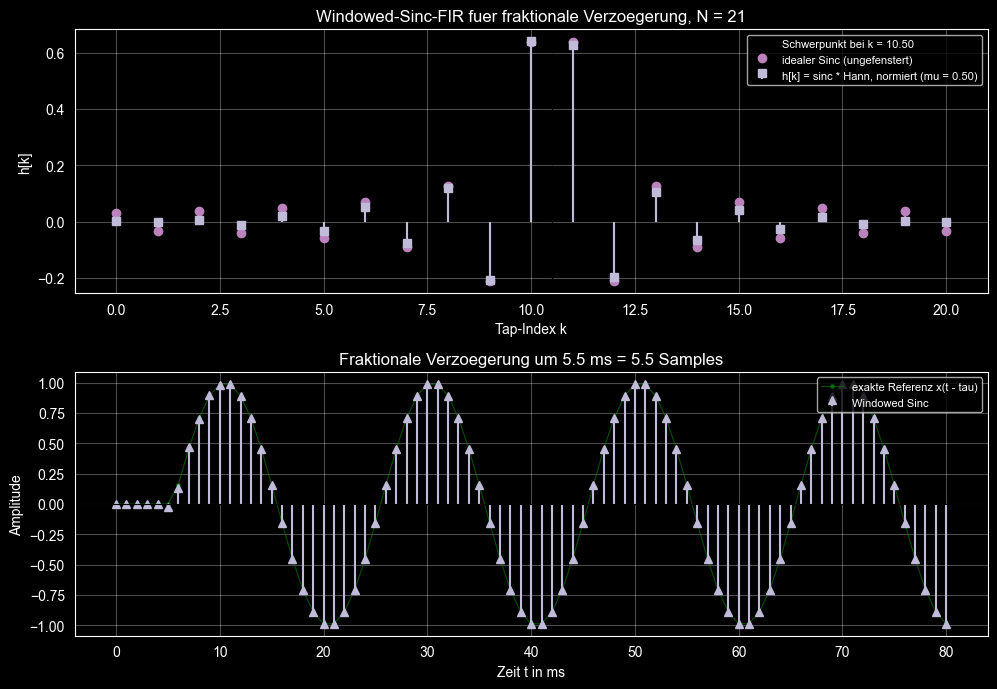

In [6]:
# Plot: Koeffizienten des Filters und Ergebnis der fraktionalen Verzoegerung
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# Impulsantwort h[k] gegen den idealen (ungefensterten) Sinc
k = np.arange(N_taps)
M = (N_taps - 1) // 2
ax[0].stem(k, np.sinc(k - M - mu), basefmt=" ", linefmt="C7-", markerfmt="C7o",
           label="idealer Sinc (ungefenstert)")
ax[0].stem(k, h, basefmt=" ", linefmt="C2-", markerfmt="C2s",
           label=f"h[k] = sinc * Hann, normiert (mu = {mu:.2f})")
ax[0].axvline(M + mu, color="k", ls="--", lw=0.8, label=f"Schwerpunkt bei k = {M+mu:.2f}")
ax[0].set_title(f"Windowed-Sinc-FIR fuer fraktionale Verzoegerung, N = {N_taps}")
ax[0].set_xlabel("Tap-Index k")
ax[0].set_ylabel("h[k]")
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=8)

# nur die exakte Referenz gegen das fraktional verzoegerte Signal
t_plot = 4 / f0                     # 4 Perioden, damit der Versatz gut sichtbar ist
mp = tn <= t_plot

ax[1].plot(tn[mp] * 1e3, xn_ref[mp], "g.-", lw=0.8, ms=5, alpha=0.6,
           label="exakte Referenz x(t - tau)")
ax[1].stem(tn[mp] * 1e3, xn_frac[mp], basefmt=" ", linefmt="C2-", markerfmt="C2^",
           label="Windowed Sinc")
ax[1].set_title(f"Fraktionale Verzoegerung um {tau_frac*1e3:.1f} ms = {tau_frac*fs:.1f} Samples")
ax[1].set_xlabel("Zeit t in ms")
ax[1].set_ylabel("Amplitude")
ax[1].grid(True, alpha=0.3)
ax[1].axhline(0, color="k", lw=0.8)
ax[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()